### Ablation experiments comparing net values of each extension (0.1%).

0.05%

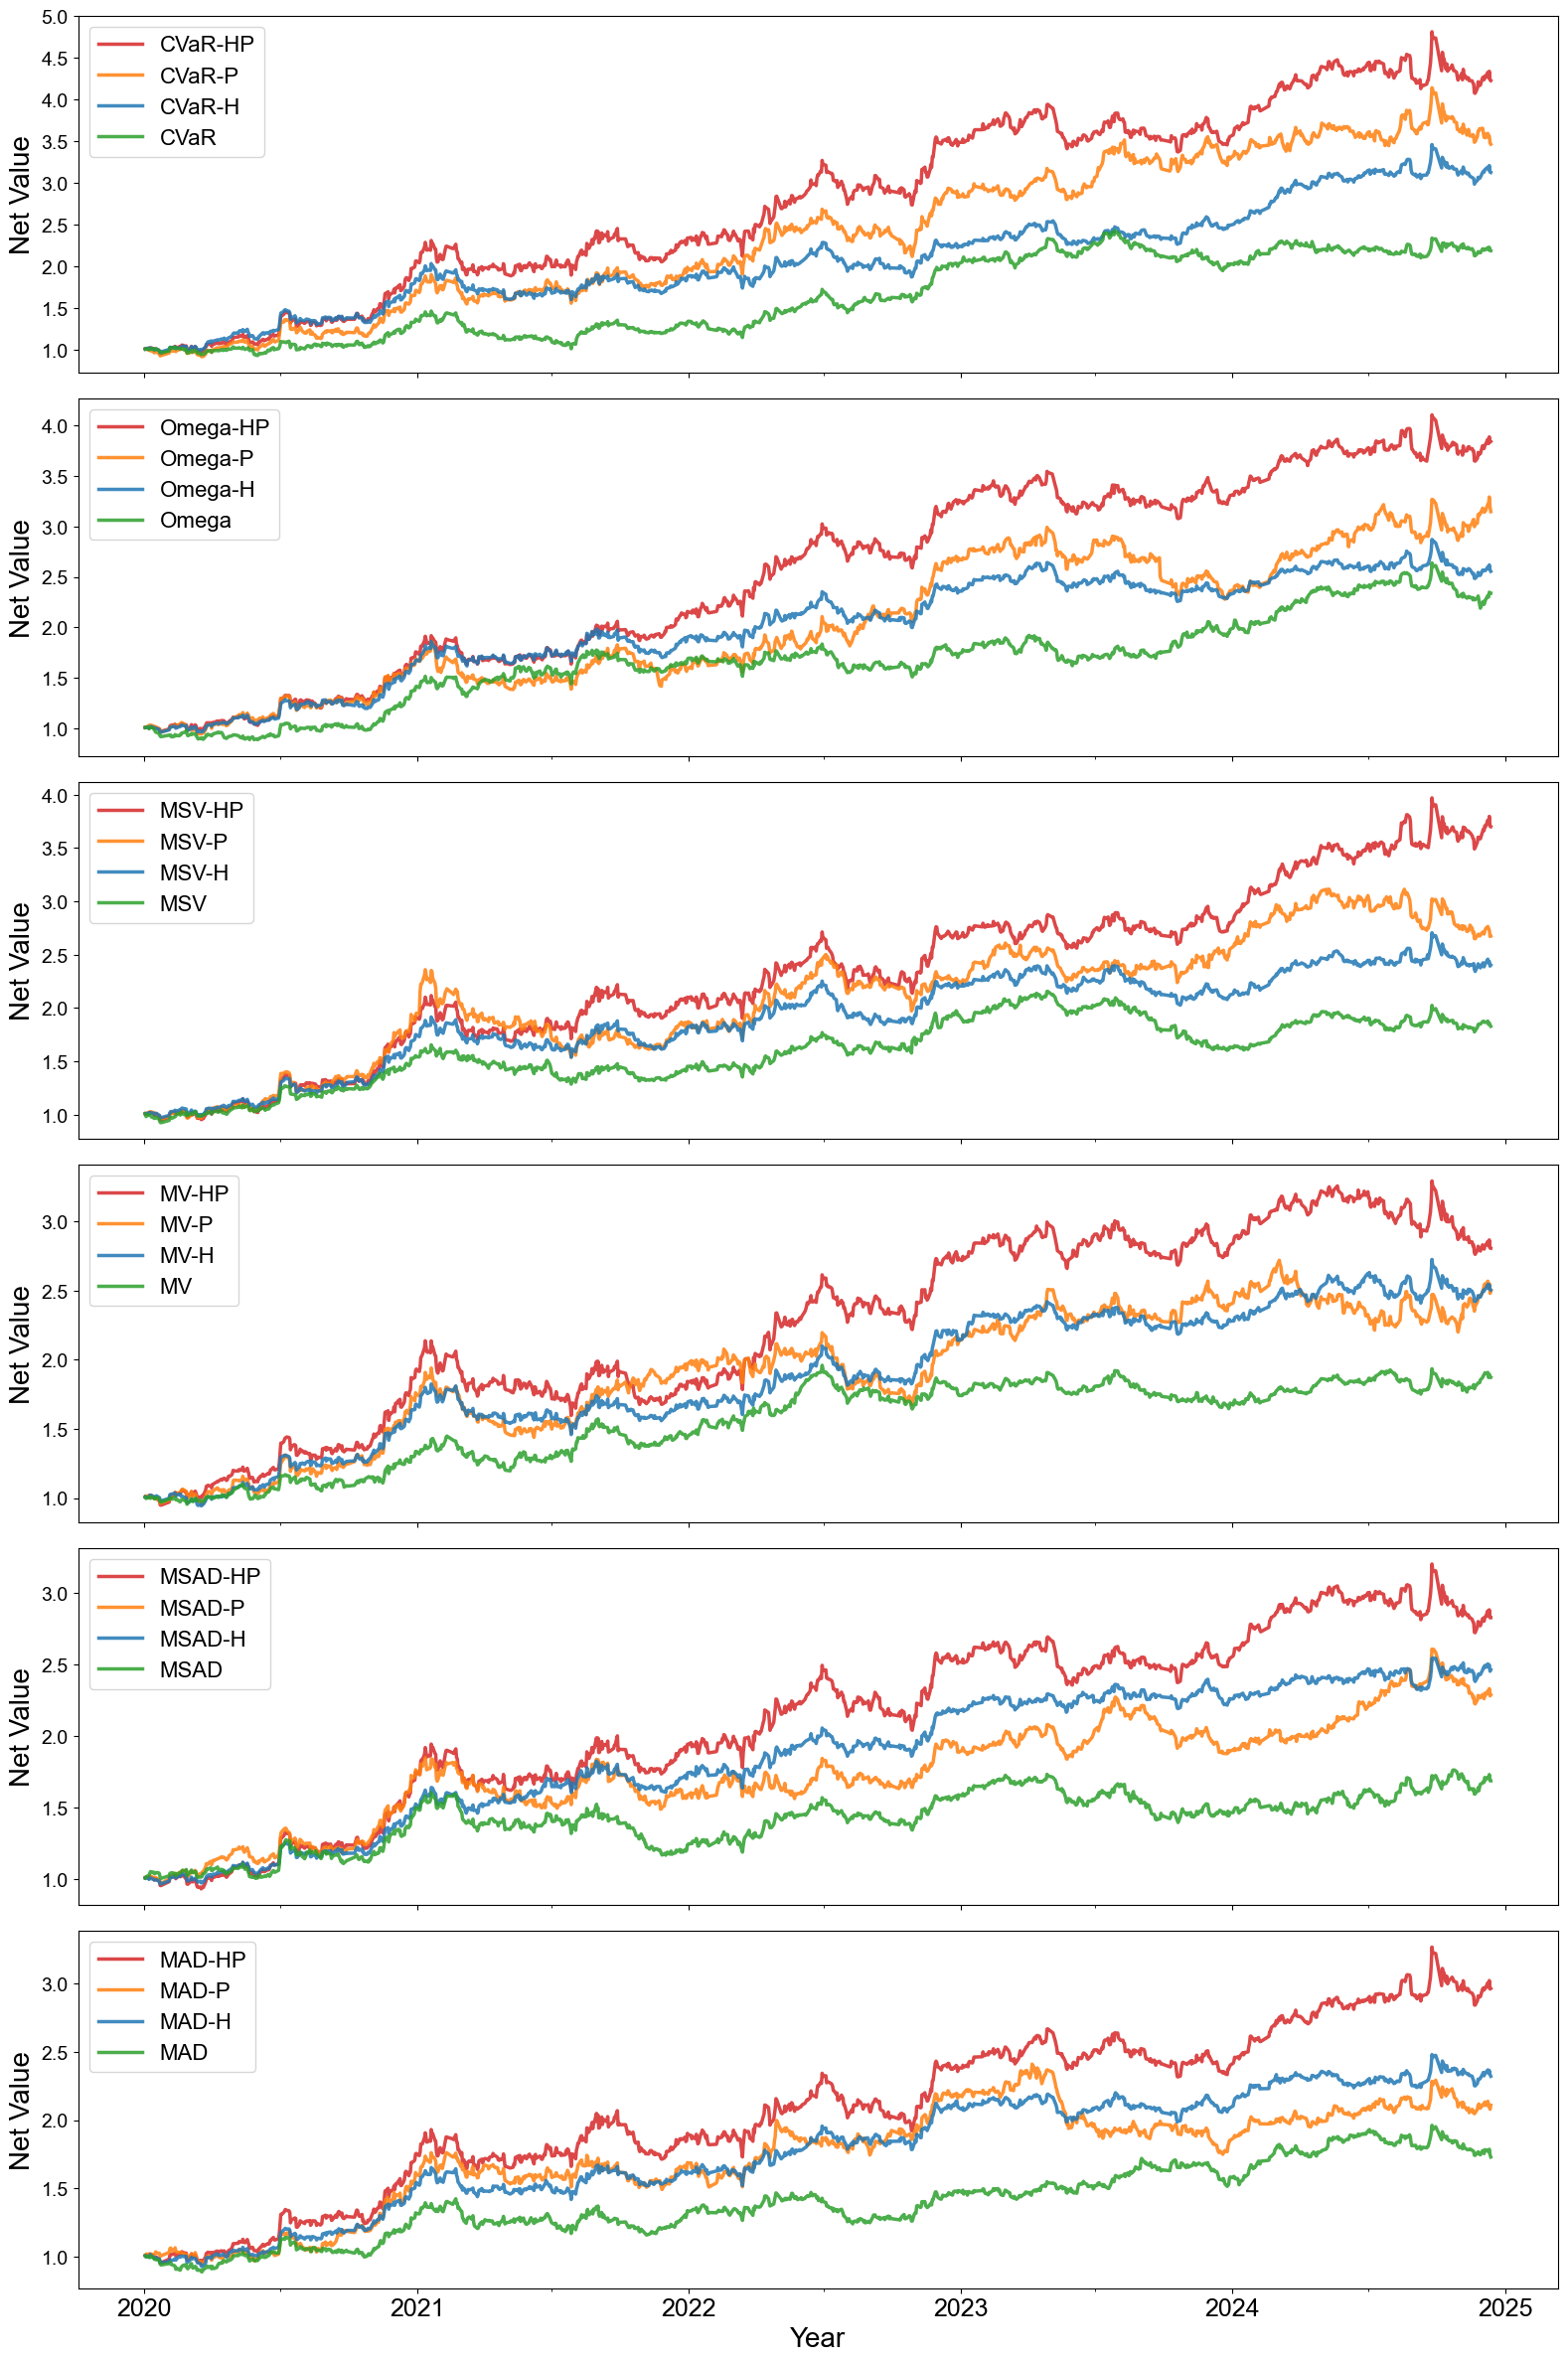

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.rcParams['font.sans-serif'] = ['Arial']

def read_model_data(model_name):
    filename = f'portfolio_daily_returns0.05.csv'
    df = pd.read_csv(filename)
    
    # 将date列转换为日期格式
    df['date'] = pd.to_datetime(df['date'])

    model_data = {
        'Original_return': df[model_name +'_Original'],
        'HigherMoments_return': df[model_name +'_HigherMoments'],
        'Predictive_return': df[model_name +'_Predictive'],
        'Integrated_return': df[model_name +'_Integrated']
    }

    return df['date'], model_data

def plot_all_models_subplot(all_dates, all_model_data, models_list):
    """
    绘制所有模型的组图,竖着排列
    """
    plt.rcParams.update({'font.size': 14})
    fig, axes = plt.subplots(6, 1, figsize=(16, 24))

    colors = {
        'Original': '#2ca02c',      # 原始绿色
        'HigherMoments': '#1f77b4', # -H蓝色
        'Predictive': '#ff7f0e',    # -P橘色
        'Integrated': '#d62728'     # -HP红色
    }
    
    for i, model_name in enumerate(models_list):
        ax = axes[i]
        dates = all_dates[model_name]
        model_data = all_model_data[model_name]

        original_cumret = (1 + model_data['Original_return']).cumprod()
        higher_cumret = (1 + model_data['HigherMoments_return']).cumprod()
        predictive_cumret = (1 + model_data['Predictive_return']).cumprod()
        integrated_cumret = (1 + model_data['Integrated_return']).cumprod()

        ax.plot(dates, integrated_cumret, 
                label=f'{model_name}-HP', 
                linewidth=2.5, alpha=0.85, color=colors['Integrated'])
        ax.plot(dates, predictive_cumret, 
                label=f'{model_name}-P', 
                linewidth=2.5, alpha=0.85, color=colors['Predictive'])
        ax.plot(dates, higher_cumret, 
                label=f'{model_name}-H', 
                linewidth=2.5, alpha=0.85, color=colors['HigherMoments'])
        ax.plot(dates, original_cumret, 
                label=f'{model_name}', 
                linewidth=2.5, alpha=0.85, color=colors['Original'])

        ax.set_ylabel('Net Value', fontsize=20)
        ax.legend(loc='best', fontsize=16)
        ax.grid(False)

        ax.xaxis.set_major_locator(mdates.YearLocator(base=1))
        ax.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=[1, 7]))

        ax.tick_params(axis='x', labelsize=14)
        ax.tick_params(axis='y', labelsize=14)

        if i == len(models_list) - 1:
            ax.set_xlabel('Year', fontsize=20)
            ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
            plt.setp(ax.xaxis.get_majorticklabels(), rotation=0, fontsize=18)
        else:
            ax.xaxis.set_major_formatter(mdates.DateFormatter(''))
            plt.setp(ax.xaxis.get_majorticklabels(), visible=False)
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    # 定义六个模型列表
    models_list = ['CVaR', 'Omega', 'MSV', 'MV', 'MSAD', 'MAD']
    all_model_data = {}
    all_dates = {}
    
    # 读取每个模型的数据
    for model_name in models_list:
        dates, model_data = read_model_data(model_name)
        all_dates[model_name] = dates
        all_model_data[model_name] = model_data
    plot_all_models_subplot(all_dates, all_model_data, models_list)

0.1%

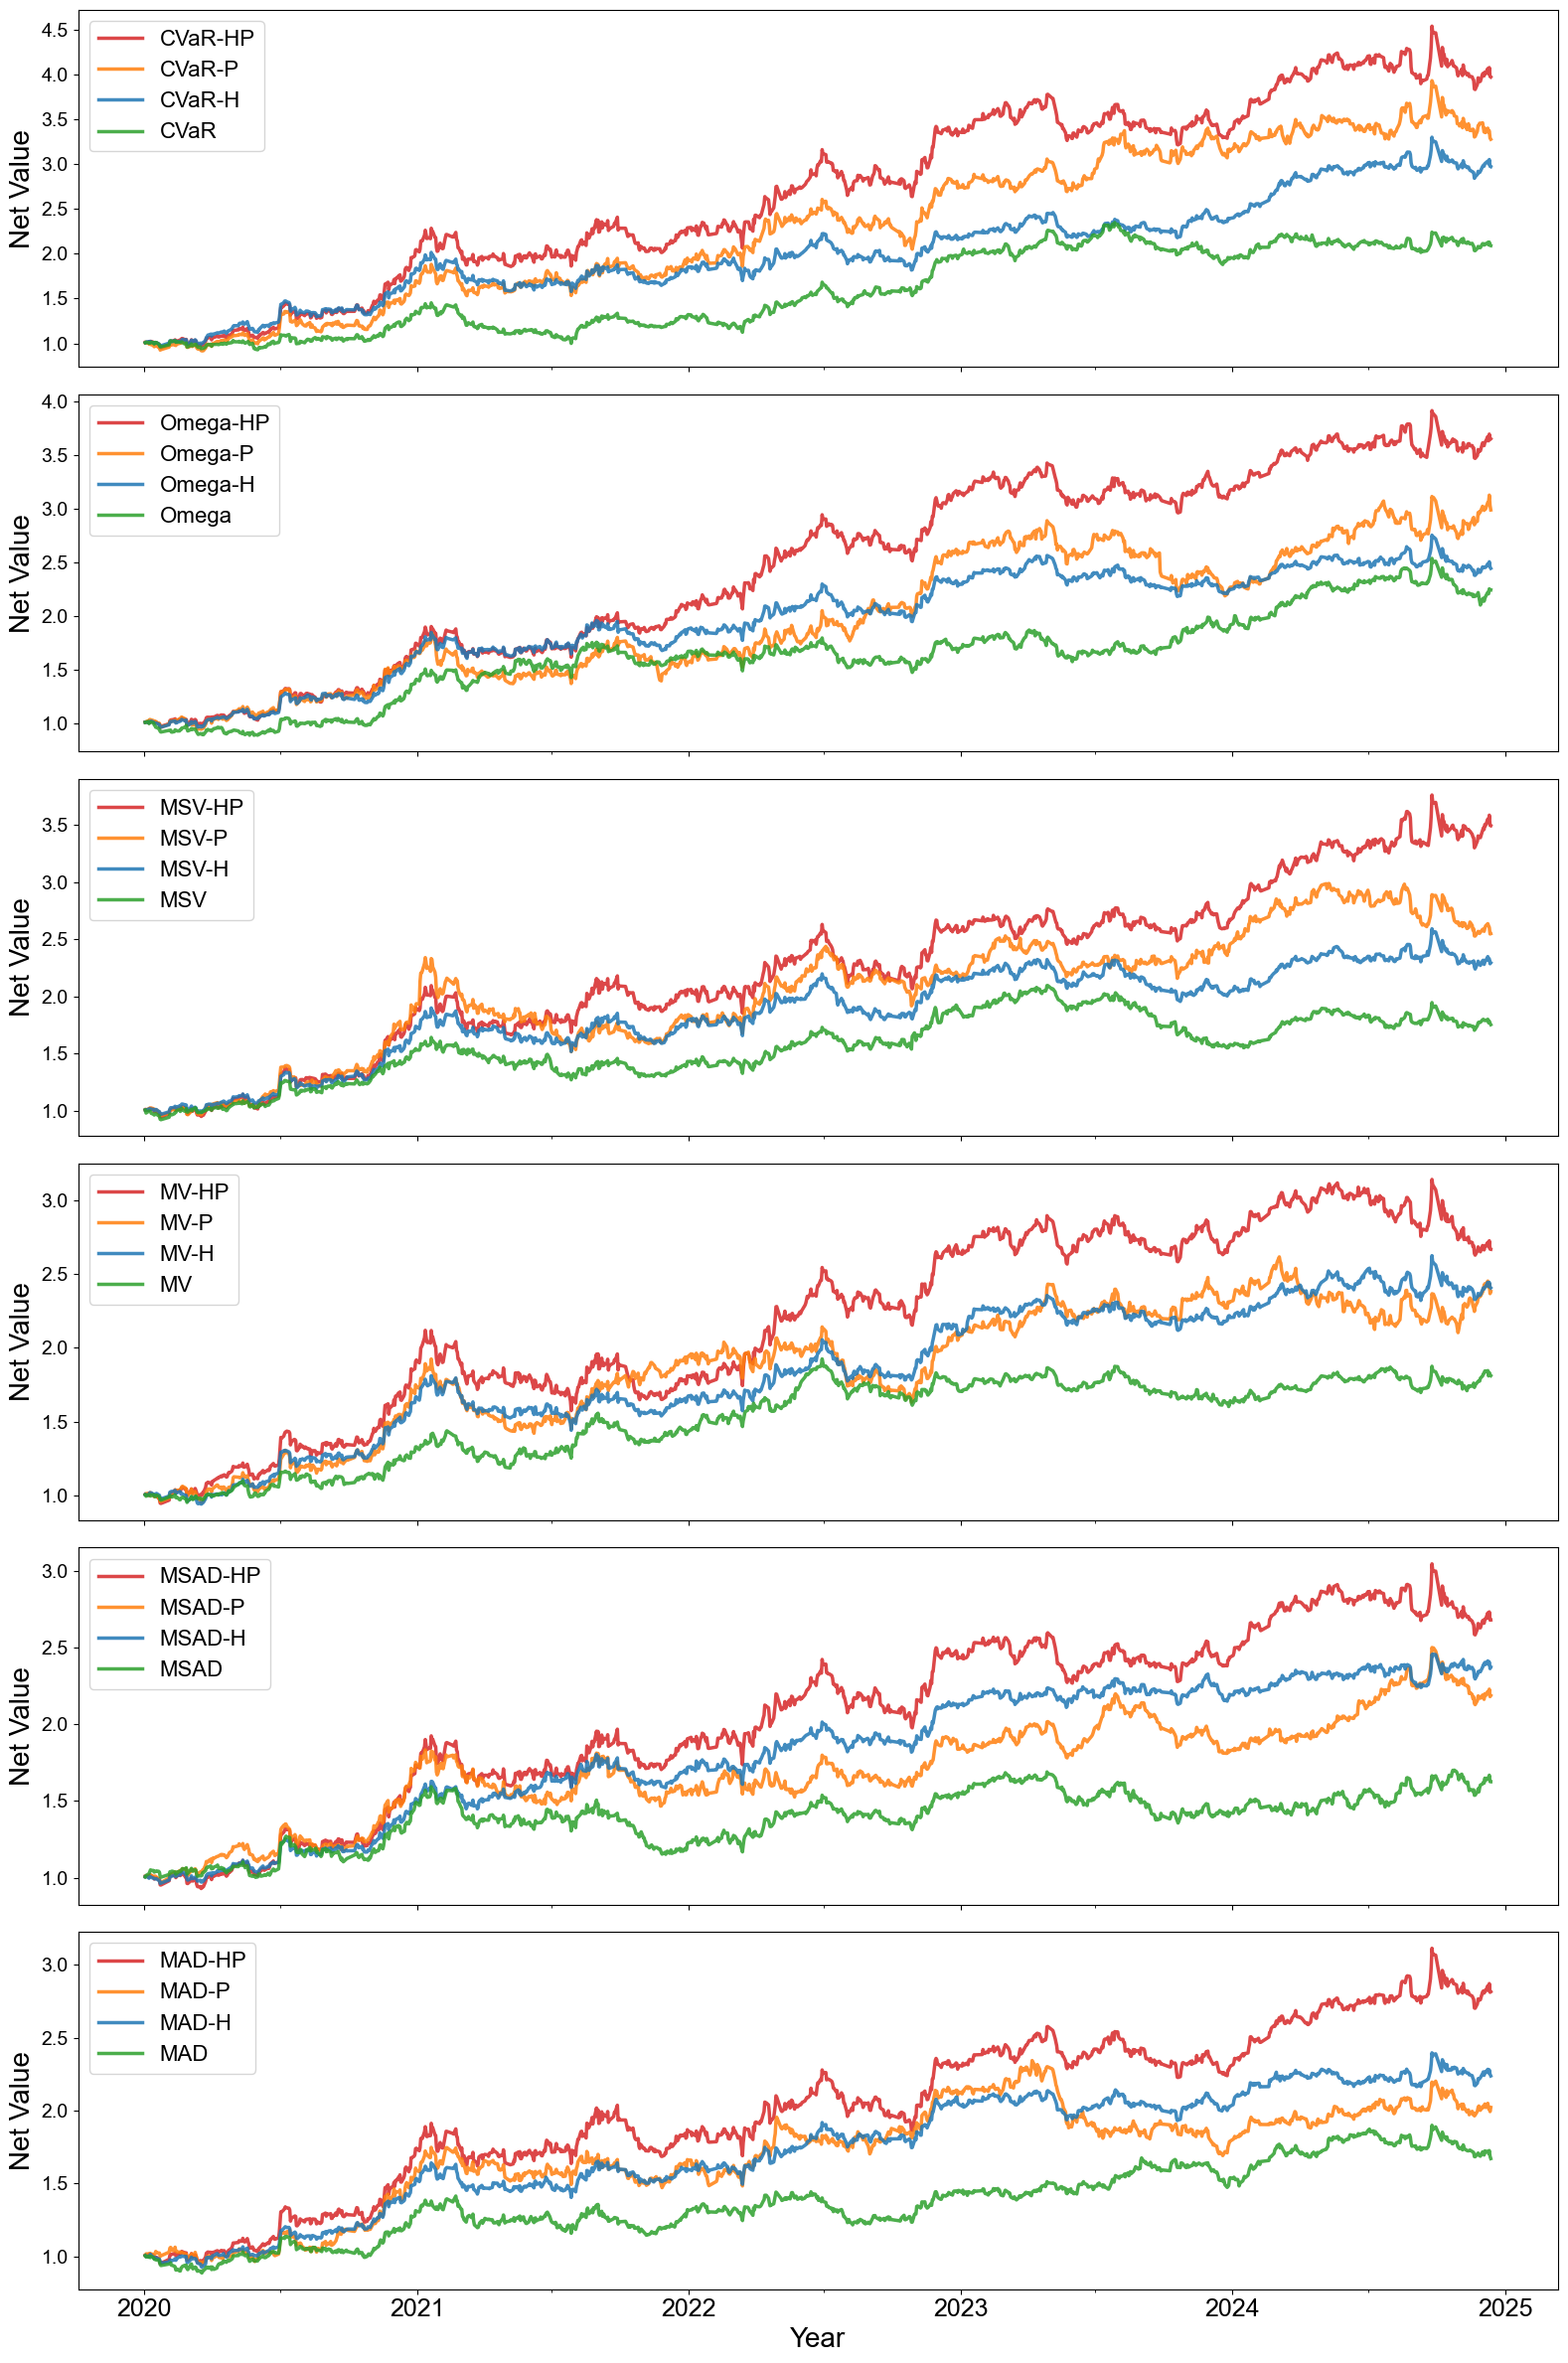

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['Arial']

def read_model_data(model_name):
    filename = f'portfolio_daily_returns0.1.csv'
    df = pd.read_csv(filename)
    
    # 将date列转换为日期格式
    df['date'] = pd.to_datetime(df['date'])

    model_data = {
        'Original_return': df[model_name +'_Original'],
        'HigherMoments_return': df[model_name +'_HigherMoments'],
        'Predictive_return': df[model_name +'_Predictive'],
        'Integrated_return': df[model_name +'_Integrated']
    }

    return df['date'], model_data

if __name__ == "__main__":
    # 定义六个模型列表
    models_list = ['CVaR', 'Omega', 'MSV', 'MV', 'MSAD', 'MAD']
    all_model_data = {}
    all_dates = {}
    
    # 读取每个模型的数据
    for model_name in models_list:
        dates, model_data = read_model_data(model_name)
        all_dates[model_name] = dates
        all_model_data[model_name] = model_data
    plot_all_models_subplot(all_dates, all_model_data, models_list)

### Net value differences between the proposed –HP extensions and their original counterparts (0.1%).

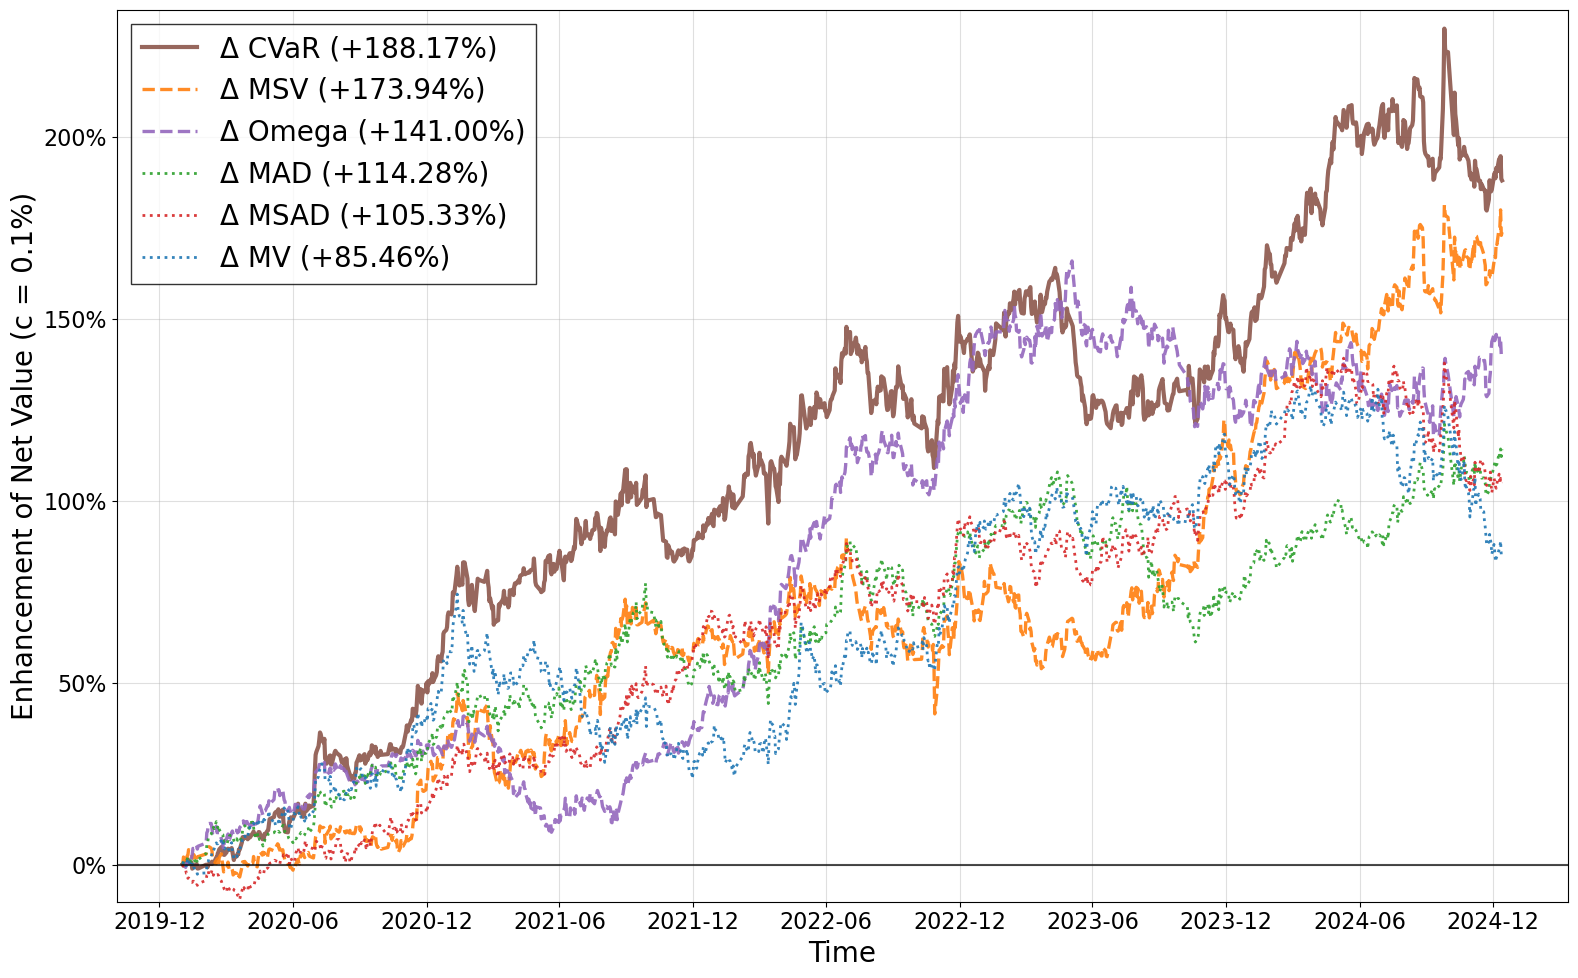

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

def plot_integrated_original_difference():

    plt.rcParams.update({'font.size': 14})
    df = pd.read_csv('portfolio_daily_returns0.1.csv')
    df['date'] = pd.to_datetime(df['date'])

    models = ['MV', 'MSV', 'MAD', 'MSAD', 'Omega', 'CVaR']

    model_final_diffs = []
    
    for model in models:
        integrated_col = f'{model}_Integrated'
        original_col = f'{model}_Original'

        if integrated_col in df.columns and original_col in df.columns:
            integrated_cumret = (1 + df[integrated_col]).cumprod() - 1
            original_cumret = (1 + df[original_col]).cumprod() - 1
            difference = integrated_cumret - original_cumret
            final_diff = difference.iloc[-1]
            
            model_final_diffs.append({
                'model': model,
                'final_diff': final_diff,
                'difference_series': difference
            })

    model_final_diffs.sort(key=lambda x: x['final_diff'], reverse=True)
    plt.figure(figsize=(16, 10))
    model_colors = {
        'CVaR': '#8c564b',
        'Omega': '#9467bd', 
        'MSV': '#ff7f0e',
        'MAD': '#2ca02c',
        'MSAD': '#d62728',
        'MV': '#1f77b4'
    }
    line_styles = ['-', '--', '--', ':', ':', ':']
    line_widths = [3.0, 2.4, 2.4, 2.0, 2.0, 2.0]
    for i, model_data in enumerate(model_final_diffs):
        model = model_data['model']
        difference = model_data['difference_series']
        final_diff = model_data['final_diff']
        plt.plot(df['date'], difference, 
                label=f'Δ {model} (+{final_diff*100:.2f}%)', 
                color=model_colors[model], 
                linewidth=line_widths[i], 
                linestyle=line_styles[i],
                alpha=0.9)
    plt.axhline(y=0, color='black', linestyle='-', alpha=0.7, linewidth=1.5)
    plt.xlabel('Time', fontsize=20)
    plt.ylabel('Enhancement of Net Value (c = 0.1%)', fontsize=20)
    plt.legend(loc='upper left', fontsize=20, frameon=True, 
              fancybox=False, shadow=False, edgecolor='black')
    plt.grid(True, alpha=0.4, linestyle='-', linewidth=0.8)
    plt.gca().xaxis.set_major_locator(mdates.MonthLocator(bymonth=[6, 12]))
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.tick_params(axis='x', labelsize=16, rotation=0)
    plt.tick_params(axis='y', labelsize=16)
    plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))
    plt.ylim(-0.1, 2.35)
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    plot_integrated_original_difference()


### Performance summary of all portfolio models under different transaction costs.

0.05%

In [ ]:
import pandas as pd
import numpy as np

def calculate_portfolio_metrics_with_cost(pre):
    """
    CR: 累计收益率 (Cumulative Return)
    ER: 超额收益率 (Excess Return) - 按照公式 ER = Σ(Rp,t - Rm,t) / T
    SD: 标准差 (Standard Deviation) - 基于月度超额收益率
    MD: 最大回撤 (Maximum Drawdown)
    IR: 信息比率 (Information Ratio) - ER / SD
    VaR: 风险价值 (Value at Risk) - 5%置信水平下的日度VaR
    CVaR: 条件风险价值 (Conditional Value at Risk) - 5%置信水平下的日度CVaR
    TUR: 平均换手率 (Turnover Rate) - 换手率的非零非第一个数据的平均值
    CR_Cost: 成本比率 (Cost Ratio) - (累计毛收益率 - 累计净收益率) / |累计净收益率|
    """
    df = pd.read_csv(f'portfolio_daily_returns{pre}.csv')
    df['date'] = pd.to_datetime(df['date'])
    turnover_df = pd.read_csv('portfolio_turnover_transformed.csv')
    turnover_df['date'] = pd.to_datetime(turnover_df['date'])

    cost_df = pd.read_csv(f'portfolio_daily_returns{pre}.csv')
    cost_df['date'] = pd.to_datetime(cost_df['date'])
    no_cost_df = pd.read_csv('portfolio_daily_returns.csv')
    no_cost_df['date'] = pd.to_datetime(no_cost_df['date'])
    cost_merged = pd.merge(cost_df, no_cost_df, on='date', how='inner', suffixes=('_with_cost', '_no_cost'))

    benchmark_df = pd.read_csv('CSI141每日收益率_2020_2024.csv') 
    benchmark_df['date'] = pd.to_datetime(benchmark_df['Date'])

    merged_df = pd.merge(df, benchmark_df, on='date', how='inner')
    merged_df = pd.merge(merged_df, turnover_df, on='date', how='inner')

    model_names =['MV', 'MSV', 'MAD', 'MSAD', 'Omega', 'CVaR']
    versions = ['Original', 'HigherMoments', 'Predictive', 'Integrated']
    
    # 步骤1: 收集投资组合列信息
    portfolio_columns = []
    turnover_columns = []
    
    for model_name in model_names:
        for version in versions:
            col_name = f'{model_name}_{version}'
            full_name = f'{model_name}-{version}'
            if version == 'Original':
                full_name = model_name  # Original版本不显示后缀
            elif version == 'HigherMoments':
                full_name = f'{model_name}-H'
            elif version == 'Predictive':
                full_name = f'{model_name}-P'
            elif version == 'Integrated':
                full_name = f'{model_name}-HP'
            
            if col_name in merged_df.columns:
                portfolio_columns.append((full_name, col_name))

            turnover_col_name = f'{model_name}_{version}_turnover'
            if turnover_col_name in merged_df.columns:
                turnover_columns.append((full_name, turnover_col_name))
    
    # 步骤2: 计算月度超额收益率
    merged_df['year_month'] = merged_df['date'].dt.to_period('M')
    
    # 先计算基准的月度收益率
    benchmark_monthly = merged_df.groupby('year_month')['CSI141_DailyReturn'].apply(
        lambda x: (1 + x).prod() - 1, include_groups=False
    )
    
    # 按月分组计算月度超额收益率
    monthly_excess_returns = {}
    monthly_data_list = []
    
    for full_name, col_name in portfolio_columns:
        # 先分别计算投资组合月度收益率
        portfolio_monthly = merged_df.groupby('year_month')[col_name].apply(
            lambda x: (1 + x).prod() - 1, include_groups=False
        )
        
        # 计算月度超额收益率: 投资组合月度收益率 - 基准月度收益率
        monthly_excess_values = portfolio_monthly - benchmark_monthly
        monthly_excess = pd.DataFrame({
            'year_month': monthly_excess_values.index,
            f'{full_name}_monthly_excess': monthly_excess_values.values
        }).reset_index(drop=True)
        
        if len(monthly_data_list) == 0:
            monthly_data_list.append(monthly_excess[['year_month', f'{full_name}_monthly_excess']])
        else:
            monthly_data_list.append(monthly_excess[[f'{full_name}_monthly_excess']])
        
        monthly_excess_returns[full_name] = monthly_excess_values
    
    # 合并所有月度数据
    if monthly_data_list:
        monthly_df = pd.concat(monthly_data_list, axis=1)
        monthly_df['year_month'] = monthly_df['year_month'].astype(str)
        monthly_df.to_csv(f'Monthly_Excess_Returns{pre}.csv', index=False, encoding='utf-8-sig')
        print(f"已保存: Monthly_Excess_Returns{pre}.csv")

    # 步骤3: 计算年度指标
    all_combinations = [full_name for full_name, _ in portfolio_columns]
    
    results = pd.DataFrame(
        index=all_combinations,
        columns=['CR', 'MD', 'ER', 'SD', 'IR', 'VaR', 'CVaR', 'TUR', 'CR_Cost']
    )
    
    for full_name, col_name in portfolio_columns:
        # 原始投资组合收益率
        portfolio_returns = merged_df[col_name]
        
        # 月度超额收益率
        if full_name in monthly_excess_returns:
            monthly_excess = monthly_excess_returns[full_name]
        else:
            continue
        
        # 1. CR: 累计收益率 (Cumulative Return)
        cumulative_return = (1 + portfolio_returns).cumprod().iloc[-1] - 1
        
        # 2. ER: 超额收益率 - 按照公式 ER = Σ(Rp,t - Rm,t) / T
        # 使用月度超额收益率计算年化ER
        ER = monthly_excess.mean()
        
        # 3. SD: 标准差 - 基于月度超额收益率的标准差
        SD = monthly_excess.std()
        
        # 4. IR: 信息比率 (Information Ratio) - ER / SD
        if SD != 0:
            IR = ER / SD
        else:
            IR = 0
        
        # 5. VaR(5%): 风险价值 - 基于日度收益率
        VaR = np.percentile(portfolio_returns, 5)
        
        # 6. CVaR(5%): 条件风险价值 - 基于日度收益率
        # CVaR是VaR以下收益率的期望值
        var_threshold = VaR
        tail_returns = portfolio_returns[portfolio_returns <= var_threshold]
        if len(tail_returns) > 0:
            CVaR = tail_returns.mean()
        else:
            CVaR = VaR
        
        # 7. MD: 最大回撤 (Maximum Drawdown) - 基于原始投资组合收益率
        cumulative_returns = (1 + portfolio_returns).cumprod()
        peak = cumulative_returns.expanding().max()
        drawdown = (cumulative_returns - peak) / peak
        max_drawdown = drawdown.min()
        
        # 8. TUR: 平均换手率 (Turnover Rate) - 换手率的非零非第一个数据的平均值
        TUR = 0
        # 找到对应的换手率列
        turnover_col_name = f'{col_name}_turnover'
        if turnover_col_name in merged_df.columns:
            turnover_data = merged_df[turnover_col_name].values
            
            # 排除第一个数据点和零值
            mask = np.ones(len(turnover_data), dtype=bool)
            mask[0] = False  # 排除第一个数据点
            mask = mask & (turnover_data != 0)  # 排除零值
            
            # 计算非零非第一个数据的平均值
            if mask.sum() > 0:
                TUR = turnover_data[mask].mean()
            else:
                TUR = 0
        
        # 9. CR_Cost: 成本比率 (Cost Ratio)
        CR_Cost = 0
        if cost_merged is not None:
            cost_return_col = f'{col_name}_with_cost'  # 净收益列
            no_cost_return_col = f'{col_name}_no_cost'  # 基础收益列
            
            if (cost_return_col in cost_merged.columns and 
                no_cost_return_col in cost_merged.columns):
                
                # 获取净收益和基础收益
                net_returns = cost_merged[cost_return_col].dropna()
                basic_returns = cost_merged[no_cost_return_col].dropna()
                
                # 确保两个序列长度相同
                min_length = min(len(net_returns), len(basic_returns))
                if min_length > 0:
                    net_returns = net_returns.iloc[:min_length]
                    basic_returns = basic_returns.iloc[:min_length]

                    gross_cumulative = (1 + basic_returns).prod() - 1  # 毛收益累计收益率
                    net_cumulative = (1 + net_returns).prod() - 1      # 净收益累计收益率
                    cost_impact = gross_cumulative - net_cumulative    # 成本影响
                    
                    # 成本比率 = 成本影响 / |净累计收益率|
                    if gross_cumulative != 0:
                        CR_Cost = cost_impact / abs(gross_cumulative)
                    else:
                        CR_Cost = 0

        
        # 将结果存入DataFrame
        results.loc[full_name, 'CR'] = f"{cumulative_return:.4f}"
        results.loc[full_name, 'MD'] = f"{max_drawdown:.4f}"
        results.loc[full_name, 'ER'] = f"{ER:.4f}"
        results.loc[full_name, 'SD'] = f"{SD:.4f}"
        results.loc[full_name, 'IR'] = f"{IR:.4f}"
        results.loc[full_name, 'VaR'] = f"{VaR:.8f}"
        results.loc[full_name, 'CVaR'] = f"{CVaR:.8f}"
        results.loc[full_name, 'TUR'] = f"{TUR:.4f}"
        results.loc[full_name, 'CR_Cost'] = f"{CR_Cost:.6f}"
    
    return results, monthly_df

def display_and_save_results_with_cost(pre):
    results_df, monthly_df = calculate_portfolio_metrics_with_cost(pre)
    
    if results_df is None:
        return None

    model_names = ['MV', 'MSV', 'MAD', 'MSAD', 'Omega', 'CVaR']
    version_order = ['', '-H', '-P', '-HP']
    
    # 创建分组显示的结果
    print("\n" + "=" * 110)
    print("Portfolio Performance Metrics")
    print("=" * 110)
    
    for model_name in model_names:
        print(f"\n{model_name} 模型系列:")
        print("-" * 100)
        for version_suffix in version_order:
            if version_suffix == '':
                full_name = model_name
            else:
                full_name = f'{model_name}{version_suffix}'
                
            if full_name in results_df.index:
                row_data = results_df.loc[full_name]
                print(f"{full_name:<10} CR={row_data['CR']:<8} MD={row_data['MD']:<8} ER={row_data['ER']:<8} SD={row_data['SD']:<8} "
                      f"IR={row_data['IR']:<8} VaR={row_data['VaR']:<8} CVaR={row_data['CVaR']:<8} "
                       f"TUR={row_data['TUR']:<8} CR_Cost={row_data['CR_Cost']:<10}")

    print("\n" + "=" * 110)

display_and_save_results_with_cost("0.05")

已保存: Monthly_Excess_Returns0.05.csv

Portfolio Performance Metrics

MV 模型系列:
----------------------------------------------------------------------------------------------------
MV         CR=0.8730   MD=-0.1736  ER=0.0060   SD=0.0510   IR=0.1174   VaR=-0.01686936 CVaR=-0.02391227 TUR=0.2495   CR_Cost=0.067910  
MV-H       CR=1.5044   MD=-0.2007  ER=0.0111   SD=0.0486   IR=0.2281   VaR=-0.01716453 CVaR=-0.02606300 TUR=0.2649   CR_Cost=0.064455  
MV-P       CR=1.4954   MD=-0.2584  ER=0.0116   SD=0.0597   IR=0.1945   VaR=-0.02189786 CVaR=-0.03212977 TUR=0.3051   CR_Cost=0.073961  
MV-HP      CR=1.8056   MD=-0.2528  ER=0.0137   SD=0.0603   IR=0.2278   VaR=-0.02149964 CVaR=-0.03165599 TUR=0.3743   CR_Cost=0.075229  

MSV 模型系列:
----------------------------------------------------------------------------------------------------
MSV        CR=0.8289   MD=-0.2568  ER=0.0057   SD=0.0497   IR=0.1142   VaR=-0.01872238 CVaR=-0.02753031 TUR=0.2615   CR_Cost=0.085711  
MSV-H      CR=1.4028   MD=-0.1

0.1%

In [2]:
display_and_save_results_with_cost("0.1")

已保存: Monthly_Excess_Returns0.1.csv

Portfolio Performance Metrics

MV 模型系列:
----------------------------------------------------------------------------------------------------
MV         CR=0.8115   MD=-0.1749  ER=0.0054   SD=0.0510   IR=0.1064   VaR=-0.01686936 CVaR=-0.02395000 TUR=0.2495   CR_Cost=0.133600  
MV-H       CR=1.4049   MD=-0.2037  ER=0.0104   SD=0.0486   IR=0.2142   VaR=-0.01716453 CVaR=-0.02609542 TUR=0.2649   CR_Cost=0.126360  
MV-P       CR=1.3814   MD=-0.2610  ER=0.0108   SD=0.0597   IR=0.1813   VaR=-0.02192612 CVaR=-0.03216828 TUR=0.3051   CR_Cost=0.144560  
MV-HP      CR=1.6660   MD=-0.2565  ER=0.0129   SD=0.0602   IR=0.2138   VaR=-0.02149964 CVaR=-0.03170720 TUR=0.3743   CR_Cost=0.146733  

MSV 模型系列:
----------------------------------------------------------------------------------------------------
MSV        CR=0.7544   MD=-0.2605  ER=0.0050   SD=0.0497   IR=0.1001   VaR=-0.01872238 CVaR=-0.02759148 TUR=0.2615   CR_Cost=0.167946  
MSV-H      CR=1.2957   MD=-0.20

### Waterfall plot visualizing the differences in gross return → transaction costs → net return for each –HP model.

0.05%

CVaR: Gross=3.4964, Cost=0.2700, Net=3.2264
Omega: Gross=3.0408, Cost=0.1985, Net=2.8422
MSV: Gross=2.9203, Cost=0.2194, Net=2.7010
MV: Gross=1.9525, Cost=0.1469, Net=1.8056
MSAD: Gross=1.9789, Cost=0.1539, Net=1.8250
MAD: Gross=2.1197, Cost=0.1567, Net=1.9630


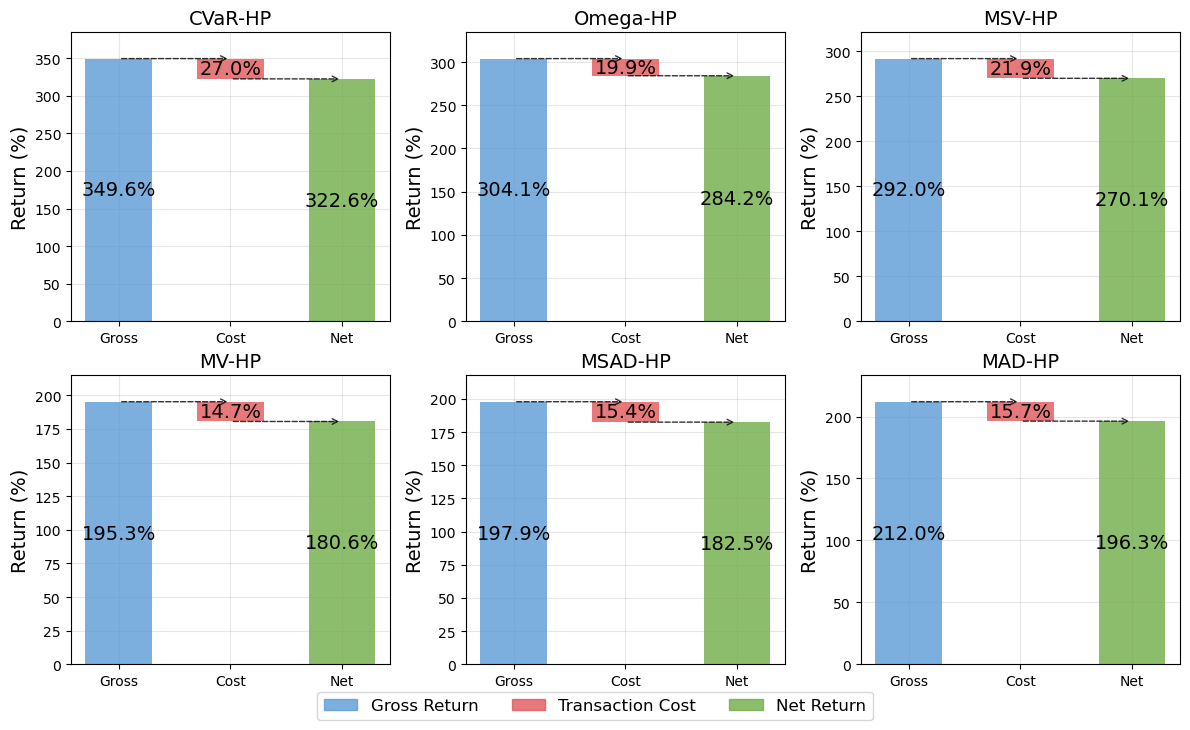

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def create_waterfall_chart(nxt):

    cost_df = pd.read_csv(f'portfolio_daily_returns{nxt}.csv')
    cost_df['date'] = pd.to_datetime(cost_df['date'])

    no_cost_df = pd.read_csv('portfolio_daily_returns.csv')
    no_cost_df['date'] = pd.to_datetime(no_cost_df['date'])

    merged_df = pd.merge(cost_df, no_cost_df, on='date', how='inner', suffixes=('_with_cost', '_no_cost'))

    models = ['CVaR', 'Omega', 'MSV', 'MV', 'MSAD', 'MAD']

    waterfall_data = []
    
    for model in models:
        # 列名
        net_col = f'{model}_Integrated_with_cost'  # 净收益
        gross_col = f'{model}_Integrated_no_cost'  # 毛收益
        
        if net_col in merged_df.columns and gross_col in merged_df.columns:
            # 计算累计收益率
            net_returns = merged_df[net_col]
            gross_returns = merged_df[gross_col]
            
            # 确保数据长度一致
            min_length = min(len(net_returns), len(gross_returns))
            if min_length > 0:
                net_returns = net_returns.iloc[:min_length]
                gross_returns = gross_returns.iloc[:min_length]
                
                # 计算累计收益率
                gross_cumulative = ((1 + gross_returns).cumprod() - 1).iloc[-1]
                net_cumulative = ((1 + net_returns).cumprod() - 1).iloc[-1]
                cost_impact = gross_cumulative - net_cumulative
                
                waterfall_data.append({
                    'Model': model,
                    'Gross': gross_cumulative * 100,  # 转换为百分比
                    'Cost': cost_impact * 100,
                    'Net': net_cumulative * 100
                })
                
                print(f"{model}: Gross={gross_cumulative:.4f}, Cost={cost_impact:.4f}, Net={net_cumulative:.4f}")

    df_waterfall = pd.DataFrame(waterfall_data)

    fig, axes = plt.subplots(2, 3, figsize=(12, 8))
    axes = axes.flatten()
    colors = {
        'Gross': '#5B9BD5',    # 蓝色
        'Cost': '#E15759',     # 红色
        'Net': '#70AD47'       # 绿色
    }
    
    for i, model in enumerate(models):
        ax = axes[i]
        model_data = df_waterfall[df_waterfall['Model'] == model].iloc[0]
        
        gross_val = model_data['Gross']
        cost_val = model_data['Cost']
        net_val = model_data['Net']
        
        # 绘制柱状图
        x_positions = [0, 1, 2]
        labels = ['Gross', 'Cost', 'Net']
        
        # Gross柱子
        ax.bar(0, gross_val, color=colors['Gross'], alpha=0.8, width=0.6)
        ax.text(0, gross_val/2, f'{gross_val:.1f}%', ha='center', va='center', 
                color='black', fontsize=14)
        
        # Cost柱子（从Gross的顶部开始向下）
        ax.bar(1, cost_val, bottom=gross_val-cost_val, color=colors['Cost'], 
                alpha=0.8, width=0.6)
        ax.text(1, gross_val - cost_val/2, f'{cost_val:.1f}%', ha='center', va='center', 
                color='black', fontsize=14)
        
        # Net柱子
        ax.bar(2, net_val, color=colors['Net'], alpha=0.8, width=0.6)
        ax.text(2, net_val/2, f'{net_val:.1f}%', ha='center', va='center', 
                color='black', fontsize=14)

        # Gross到Cost的连接线
        ax.annotate('', xy=(1, gross_val), xytext=(0, gross_val),
                    arrowprops=dict(arrowstyle='->', linestyle='--', 
                                    color='black', alpha=0.8))
        
        # Cost到Net的连接线
        ax.annotate('', xy=(2, net_val), xytext=(1, net_val),
                    arrowprops=dict(arrowstyle='->', linestyle='--', 
                                    color='black', alpha=0.8))

        ax.set_xticks(x_positions)
        ax.set_xticklabels(labels)
        ax.set_title(f'{model}-HP', fontsize=14)
        ax.set_ylabel('Return (%)', fontsize=14)
        y_max = max(gross_val, net_val) * 1.1
        y_min = min(0, net_val * 0.9)
        ax.set_ylim(y_min, y_max)
        ax.grid(True, alpha=0.3)
        ax.set_axisbelow(True)

    legend_elements = [
        mpatches.Patch(color=colors['Gross'], alpha=0.8, label='Gross Return'),
        mpatches.Patch(color=colors['Cost'], alpha=0.8, label='Transaction Cost'),
        mpatches.Patch(color=colors['Net'], alpha=0.8, label='Net Return')
    ]
    fig.legend(handles=legend_elements, loc='lower center', ncol=3, 
              bbox_to_anchor=(0.5, 0.03), fontsize=12)
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.9, bottom=0.11)
    plt.show()
    return df_waterfall

waterfall_data = create_waterfall_chart(0.05)

0.1%

CVaR: Gross=3.4964, Cost=0.5239, Net=2.9725
Omega: Gross=3.0408, Cost=0.3874, Net=2.6534
MSV: Gross=2.9203, Cost=0.4265, Net=2.4938
MV: Gross=1.9525, Cost=0.2865, Net=1.6660
MSAD: Gross=1.9789, Cost=0.2998, Net=1.6791
MAD: Gross=2.1197, Cost=0.3055, Net=1.8142


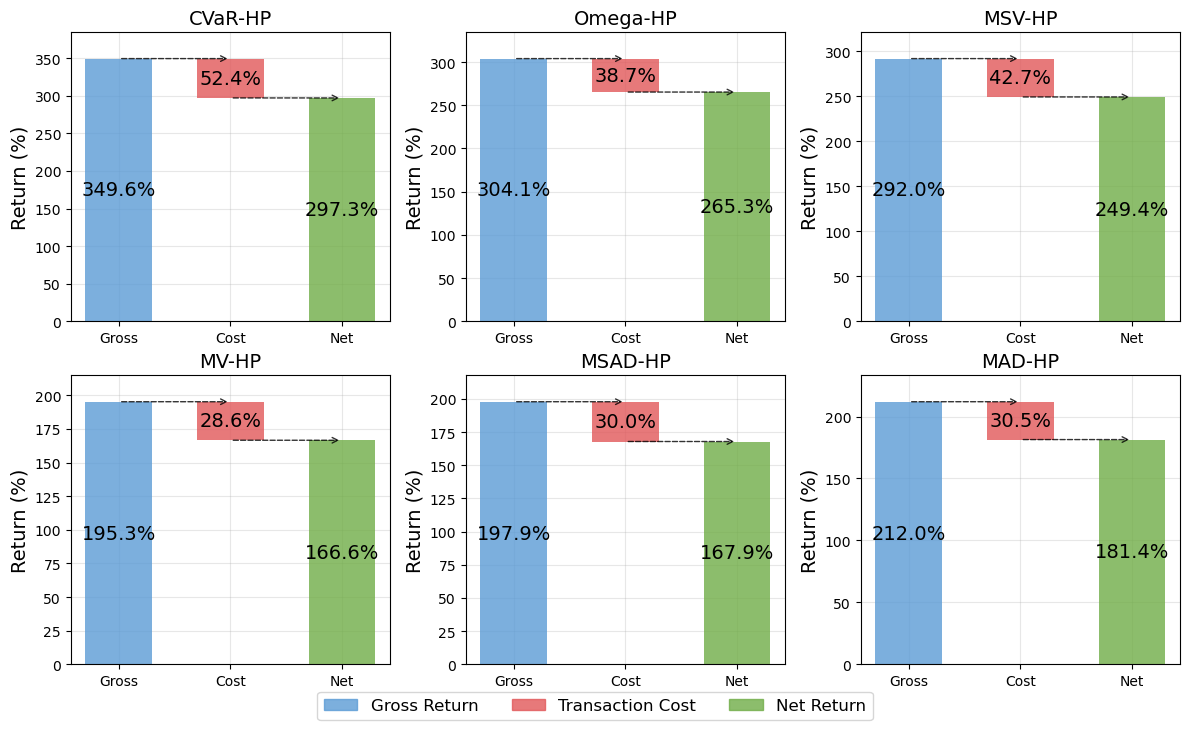

In [4]:
waterfall_data = create_waterfall_chart(0.1)

### Newey-West test with the same objective as described in 4.5.1.

In [3]:
import pandas as pd
import numpy as np
from scipy import stats
from statsmodels.regression.linear_model import OLS

def newey_west_test(returns, lags=None, risk_free_rate=0.03/365):
    """
    对收益率序列进行Newey-West检验（检验超额收益率均值是否显著不为0）
    """
    if lags is None:
        T = len(returns)
        lags = int(4 * (T/100)**(2/9)) 
    
    # 计算超额收益率
    excess_returns = returns - risk_free_rate
    
    # 准备数据进行回归
    y = excess_returns.values
    X = np.ones((len(y), 1))
    
    # 使用statsmodels进行回归并计算Newey-West标准误
    model = OLS(y, X)
    results = model.fit(cov_type='HAC', cov_kwds={'maxlags': lags})
    
    # 提取系数、标准误、t统计量和p值
    coef = results.params[0]
    std_err = results.bse[0]
    t_stat = results.tvalues[0]
    p_value = results.pvalues[0]
    
    return {
        'coefficient': coef,
        'std_error': std_err,
        't_statistic': t_stat,
        'p_value': p_value
    }

def create_newey_west_table(nxt):
    """
    创建Newey-West检验表格
    """
    df = pd.read_csv(f'portfolio_daily_returns{nxt}.csv')
    df['date'] = pd.to_datetime(df['date'])

    # 提取Integrated模型（HP）的数据
    integrated_models = {}
    model_names =['MV', 'MSV', 'MAD', 'MSAD', 'Omega', 'CVaR']
    
    for model_name in model_names:
        col_name = f'{model_name}_Integrated'
        integrated_models[f'{model_name}-HP'] = df[col_name]

    # Newey-West Test
    print("=" * 80)
    print(f"Newey-West Test Results  {nxt}%")
    print("=" * 80)
    
    nw_results = []
    
    for model_name, returns in integrated_models.items():
        nw_result = newey_west_test(returns)
        
        # 收益率
        return_with_sig = f"{nw_result['coefficient']:.6f}"
        
        # T值
        t_value_str = f"{nw_result['t_statistic']:.4f}"
        
        # p值
        p_value_str = f"{nw_result['p_value']:.4f}"
        
        nw_results.append({
            'Model': model_name,
            'Return': f"{returns.mean():.6f}",
            'SD': f"{returns.std():.6f}",
            'Skew': f"{stats.skew(returns):.4f}",
            'Kurt': f"{stats.kurtosis(returns, fisher=True):.4f}",
            'Excess Return': return_with_sig,
            'T-value': t_value_str,
            'P-value': p_value_str
        })
    
    nw_df = pd.DataFrame(nw_results)
    print(nw_df.to_string(index=False))
    nw_df.to_csv(f'Newey_West_Results{nxt}.csv', index=False, encoding='utf-8-sig')

result = create_newey_west_table(0.05)
print("\n")
result = create_newey_west_table(0.1)

Newey-West Test Results  0.05%
   Model   Return       SD   Skew   Kurt Excess Return T-value P-value
   MV-HP 0.000962 0.014280 0.0982 2.9151      0.000880  2.2525  0.0243
  MSV-HP 0.001218 0.015960 0.0597 3.2732      0.001136  2.6485  0.0081
  MAD-HP 0.001003 0.014007 0.0600 3.4717      0.000921  2.4592  0.0139
 MSAD-HP 0.000970 0.014461 0.1081 3.5440      0.000888  2.2850  0.0223
Omega-HP 0.001216 0.013717 0.1450 3.0513      0.001134  3.1415  0.0017
 CVaR-HP 0.001342 0.016781 0.1215 3.4855      0.001260  2.8042  0.0050


Newey-West Test Results  0.1%
   Model   Return       SD   Skew   Kurt Excess Return T-value P-value
   MV-HP 0.000919 0.014281 0.0972 2.9281      0.000837  2.1454  0.0319
  MSV-HP 0.001170 0.015961 0.0575 3.2891      0.001088  2.5385  0.0111
  MAD-HP 0.000961 0.014009 0.0584 3.4875      0.000878  2.3461  0.0190
 MSAD-HP 0.000926 0.014464 0.1065 3.5596      0.000844  2.1728  0.0298
Omega-HP 0.001174 0.013721 0.1433 3.0636      0.001092  3.0273  0.0025
 CVaR-HP 0.001